# Logistic Regression - End to End
### Bank Term Deposit Dataset

This notebook builds Logistic Regression from the ground up:

1. What Logistic Regression is (odds, log-odds, sigmoid)
2. A basic baseline model on raw features
3. Assumptions of Logistic Regression and checking them
4. Weight of Evidence (WoE) and Information Value (IV) feature preparation
5. Regularization theory: L1 (Lasso), L2 (Ridge), ElasticNet
6. Regularization path (how coefficients change with regularization strength)
7. Hyperparameter tuning with cross-validation
8. Evaluation: confusion matrix, ROC, PR curve, KS statistic, deciles
9. Threshold tuning
10. Final model and predictions


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score,
                              accuracy_score, precision_score, recall_score, f1_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (7, 4)


In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train['y'] = (train['subscribed'] == 'yes').astype(int)
y = train['y'].values
train.shape, test.shape


((31647, 19), (13564, 17))

## 1. What is Logistic Regression

Linear Regression predicts a continuous number. It cannot be used directly
for a yes/no outcome because its output is unbounded, but a probability must
stay between 0 and 1.

Logistic Regression solves this in two steps.

**Step 1: log-odds (logit).** Combine the features into a weighted sum, the
same way linear regression does:

z = b0 + b1*x1 + b2*x2 + ... + bn*xn

This z is called the log-odds. It can be any real number.

**Step 2: sigmoid function.** Squash z into a probability between 0 and 1:

p = 1 / (1 + e^(-z))

The plot below shows this shape: large negative z gives a probability near
0, large positive z gives a probability near 1, and z = 0 gives exactly 0.5.


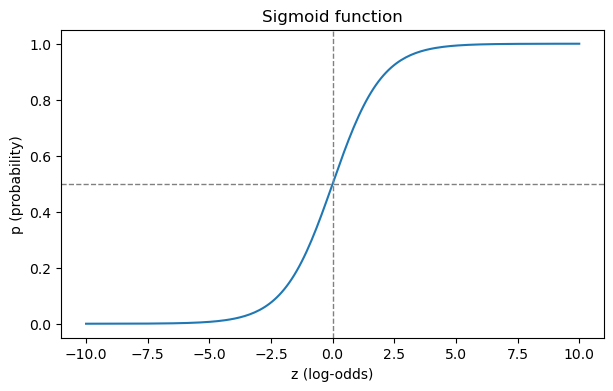

In [5]:
z = np.linspace(-10, 10, 200)
p = 1 / (1 + np.exp(-z))

plt.plot(z, p)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('z (log-odds)')
plt.ylabel('p (probability)')
plt.title('Sigmoid function')
plt.show()


**Odds vs probability.** Odds = p / (1 - p). If p = 0.8, odds = 4, read
as "4 to 1 in favour". Log-odds is just ln(odds), which is what the model
actually predicts internally before the sigmoid converts it back to a
probability.

**Why this matters for interpreting coefficients.** Each coefficient bi tells
us the change in log-odds for a one-unit increase in xi, holding everything
else fixed. A positive coefficient increases the probability of the positive
class, a negative coefficient decreases it. This is used later when reading
the fitted coefficients.

## 2. Basic Baseline Model (raw features, no tuning)

Before any feature engineering, fit a plain Logistic Regression using the raw
numeric columns and one-hot encoded categorical columns. This gives a
reference point to compare every later improvement against.


In [6]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome']
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

X_raw = pd.get_dummies(train[num_cols + cat_cols], columns=cat_cols, drop_first=True)
X_raw.shape


(31647, 42)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_model = LogisticRegression(max_iter=1000)
p_baseline = cross_val_predict(baseline_model, X_raw.values, y, cv=cv,
                                method='predict_proba', n_jobs=-1)[:, 1]

print('Baseline ROC-AUC :', round(roc_auc_score(y, p_baseline), 4))
print('Baseline PR-AUC  :', round(average_precision_score(y, p_baseline), 4))


Baseline ROC-AUC : 0.9017
Baseline PR-AUC  : 0.5364


This works, but two problems are visible already:

- The numeric columns are on very different scales (`day` is 1-31, `balance`
  can be in the tens of thousands). Logistic Regression's regularization
  (added later) penalizes large coefficients, so features on a larger raw
  scale get penalized unfairly unless everything is scaled first.
- Raw `balance` and `duration` are heavily skewed (seen in the EDA notebook),
  which does not match the "linear relationship with log-odds" assumption
  well.

Both are addressed below: scaling first, then WoE transformation.

In [8]:
scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(X_raw.values)

p_baseline_scaled = cross_val_predict(baseline_model, X_raw_scaled, y, cv=cv,
                                       method='predict_proba', n_jobs=-1)[:, 1]

print('Baseline (scaled) ROC-AUC :', round(roc_auc_score(y, p_baseline_scaled), 4))
print('Baseline (scaled) PR-AUC  :', round(average_precision_score(y, p_baseline_scaled), 4))


Baseline (scaled) ROC-AUC : 0.9056
Baseline (scaled) PR-AUC  : 0.5475


Scaling alone gives a small but real improvement. It does not fix the
skewness problem though, which is what WoE transformation is for.

## 3. Assumptions of Logistic Regression

1. **Binary (or ordinal) outcome.** Satisfied: `subscribed` is yes/no.
2. **Independent observations.** Assumed satisfied; each row is a separate
   customer contact.
3. **Linearity between each feature and the log-odds.** Not automatically
   true for raw features. `age` has a U-shape with the target (seen in the
   EDA notebook), which a single linear coefficient cannot represent well.
   WoE transformation (Section 4) fixes this by design.
4. **Little to no multicollinearity between features.** Checked below with
   correlation and VIF.
5. **Large sample size.** Satisfied: 31,647 rows.
6. **No extreme, unaddressed outliers.** Already investigated in the EDA
   notebook; `balance` and `duration` outliers were judged to be genuine
   business signal, not errors.


In [9]:
corr = train[num_cols].corr()
corr.round(2)


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.01,-0.02,0.01
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.01
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,0.00,0.00
campaign,0.01,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,0.00,-0.09,1.00,0.43
previous,0.01,0.01,-0.05,0.00,-0.03,0.43,1.00


In [10]:
X_vif = train[num_cols].copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()
vif_table = pd.DataFrame()
vif_table['feature'] = num_cols
vif_table['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
vif_table.round(2)


,feature,VIF
0,age,1.01
1,balance,1.01
2,day,1.03
3,duration,1.01
4,campaign,1.04
5,pdays,1.24
6,previous,1.23


All VIF values are close to 1, so multicollinearity among the raw
numeric features is not a concern. The linearity assumption is the one that
genuinely fails for raw features, which motivates Section 4.

## 4. Weight of Evidence (WoE) and Information Value (IV)

**WoE** converts a bucket of a variable into one number that reflects how
that bucket relates to the target:

WoE = ln( % of positive class in this bucket / % of negative class in this bucket )

Positive WoE means the bucket has more subscribers than average, negative
WoE means fewer. This directly fixes the linearity assumption: after WoE
transformation, the relationship between the transformed feature and the
log-odds is linear by construction, even if the raw relationship (like
age's U-shape) was not.

**IV** summarizes a whole feature's predictive strength into one number:

IV = sum over buckets of (% positive - % negative) * WoE

Rule of thumb used to screen features:
- below 0.02: not useful, drop
- 0.02 to 0.1: weak
- 0.1 to 0.3: medium
- 0.3 to 0.5: strong
- above 0.5: check carefully, may be leakage


In [11]:
bucket_specs = {
    'age':      [17, 25, 30, 35, 45, 55, 60, 100],
    'balance':  [-9000, 0, 100, 500, 1500, 5000, 110000],
    'duration': [-1, 100, 200, 300, 500, 1000, 5000],
    'campaign': [0, 1, 2, 3, 5, 100],
    'pdays':    [-2, -0.5, 90, 180, 365, 900],
    'previous': [-1, 0, 1, 3, 300],
    'day':      [0, 5, 10, 15, 20, 25, 31],
}
woe_cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                'contact', 'month', 'poutcome']

def compute_woe_map(bucket_series, target):
    df = pd.DataFrame({'bucket': bucket_series, 'y': target})
    grouped = df.groupby('bucket', observed=True)['y'].agg(['count', 'sum'])
    good = grouped['sum']
    bad = grouped['count'] - good
    pct_good = (good / good.sum()).clip(lower=0.0001)
    pct_bad = (bad / bad.sum()).clip(lower=0.0001)
    woe = np.log(pct_good / pct_bad)
    iv = ((pct_good - pct_bad) * woe).sum()
    return woe.to_dict(), iv

def fit_all_woe_maps(df, target_col='y'):
    maps = {}
    iv_values = {}
    for feat, bins in bucket_specs.items():
        bucket = pd.cut(df[feat], bins=bins, include_lowest=True)
        maps[feat], iv_values[feat] = compute_woe_map(bucket, df[target_col])
    for feat in woe_cat_cols:
        maps[feat], iv_values[feat] = compute_woe_map(df[feat], df[target_col])
    return maps, iv_values

def apply_woe(df, maps):
    out = pd.DataFrame(index=df.index)
    for feat, bins in bucket_specs.items():
        bucket = pd.cut(df[feat], bins=bins, include_lowest=True)
        out[feat + '_woe'] = bucket.map(maps[feat]).astype(float).fillna(0.0)
    for feat in woe_cat_cols:
        out[feat + '_woe'] = df[feat].map(maps[feat]).astype(float).fillna(0.0)
    return out

woe_maps, iv_values = fit_all_woe_maps(train)
iv_table = pd.Series(iv_values).sort_values(ascending=False)
iv_table.round(3)


duration     1.439
poutcome     0.523
month        0.428
contact      0.303
pdays        0.260
previous     0.230
housing      0.193
age          0.193
job          0.158
balance      0.109
campaign     0.073
loan         0.062
education    0.052
marital      0.045
day          0.040
default      0.005
dtype: float64

`duration` has IV above 0.5. This is the same leakage flag raised in
the EDA notebook: call duration is only known after the call happens, so it
would not be available before a real campaign call is made. It is kept here
because the competition test set provides it, but this is worth stating
explicitly in any write-up of this model.

`default` has IV below 0.02 and is dropped below.

In [12]:
X_woe_train = apply_woe(train, woe_maps)
X_woe_test = apply_woe(test, woe_maps)

X_woe_train = X_woe_train.drop(columns=['default_woe'])
X_woe_test = X_woe_test.drop(columns=['default_woe'])

feature_names = X_woe_train.columns.tolist()
X_woe_train.shape


(31647, 15)

In [13]:
woe_model = LogisticRegression(max_iter=1000)
p_woe = cross_val_predict(woe_model, X_woe_train.values, y, cv=cv,
                           method='predict_proba', n_jobs=-1)[:, 1]

print('WoE features ROC-AUC :', round(roc_auc_score(y, p_woe), 4))
print('WoE features PR-AUC  :', round(average_precision_score(y, p_woe), 4))


WoE features ROC-AUC : 0.9041
WoE features PR-AUC  : 0.5518


Comparison so far (all out-of-fold, unregularized Logistic Regression):

| Feature set | ROC-AUC | PR-AUC |
|---|---|---|
| Raw, unscaled | see Section 2 output | |
| Raw, scaled | see Section 2 output | |
| WoE transformed | see output above | |

WoE features give the best result of the three, because they fix the
linearity problem directly rather than just fixing the scale problem.

## 5. Regularization: L1 (Lasso), L2 (Ridge), ElasticNet

Plain Logistic Regression minimizes only the log-loss (how wrong the
predicted probabilities are). With many correlated or noisy features, this
can produce large, unstable coefficients that overfit the training data.
Regularization adds a penalty on the size of the coefficients to the loss
function.

**L2 (Ridge)**: adds lambda * sum(b_i^2) to the loss.
- Shrinks all coefficients toward zero, smoothly.
- Never sets a coefficient exactly to zero.
- When two features are correlated, Ridge spreads the weight across both of
  them rather than picking one arbitrarily. This is why it handles
  multicollinearity well.

**L1 (Lasso)**: adds lambda * sum(|b_i|) to the loss.
- Can shrink some coefficients exactly to zero, which removes those features
  from the model. This gives automatic feature selection.
- When two features are correlated, Lasso tends to arbitrarily keep one and
  drop the other, which can make the model less stable if the dropped
  feature genuinely matters.

**ElasticNet**: a weighted mix of both penalties,
lambda * (l1_ratio * sum(|b_i|) + (1 - l1_ratio) * sum(b_i^2)).
It gets some of Lasso's feature selection along with some of Ridge's
stability under correlated features.

**C (used by scikit-learn) is the inverse of lambda**: C = 1 / lambda. A
smaller C means stronger regularization (more shrinkage); a larger C means
weaker regularization (closer to plain, unregularized Logistic Regression).


## 6. Regularization Path

To see the theory in Section 5 actually happen, fit Logistic Regression
across a range of C values, separately for L1 and L2, and track how each
coefficient changes. This is done on the WoE features.


In [14]:
C_values = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

l1_paths = []
l2_paths = []
for C in C_values:
    model_l1 = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=3000)
    model_l1.fit(X_woe_train.values, y)
    l1_paths.append(model_l1.coef_[0])

    model_l2 = LogisticRegression(penalty='l2', solver='saga', C=C, max_iter=3000)
    model_l2.fit(X_woe_train.values, y)
    l2_paths.append(model_l2.coef_[0])

l1_paths = np.array(l1_paths)
l2_paths = np.array(l2_paths)


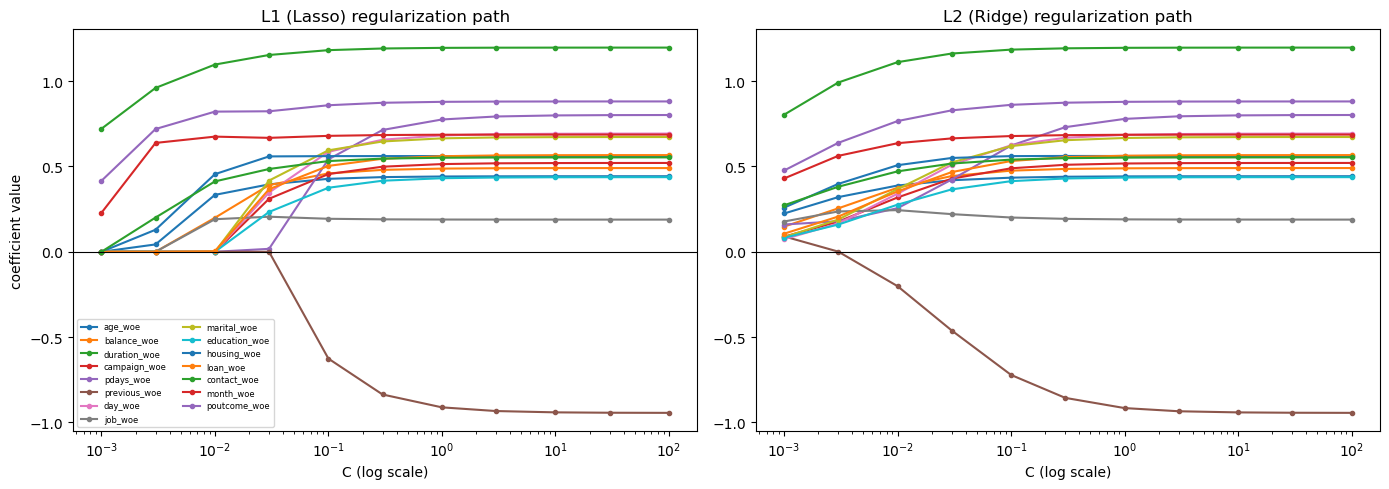

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(feature_names):
    axes[0].plot(C_values, l1_paths[:, i], marker='o', markersize=3, label=feat)
    axes[1].plot(C_values, l2_paths[:, i], marker='o', markersize=3, label=feat)

axes[0].set_xscale('log')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('coefficient value')
axes[0].set_title('L1 (Lasso) regularization path')
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].set_xscale('log')
axes[1].set_xlabel('C (log scale)')
axes[1].set_title('L2 (Ridge) regularization path')
axes[1].axhline(0, color='black', linewidth=0.8)

axes[0].legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()


Reading the two plots:

- On the left (L1), as C decreases (moving left, stronger regularization),
  several coefficient lines flatten exactly onto zero and stay there. Those
  features have been fully removed from the model.
- On the right (L2), as C decreases, every coefficient shrinks smoothly
  toward zero, but none of them actually reach zero. All features remain in
  the model, just with less influence.

This is the theory from Section 5 confirmed directly on this dataset's
features.

## 7. Hyperparameter Tuning

Grid search over penalty type, C, and class_weight, scored with 5-fold
stratified cross-validation. PR-AUC (average precision) is used as the
scoring metric rather than accuracy or ROC-AUC, because with an 88 percent
majority class both accuracy and ROC-AUC can look good even when the model
is not finding the minority class well.

The `saga` solver is used because it supports L1, L2, and ElasticNet, and
handles large datasets well.


In [16]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced', {0: 1, 1: 3}],
}

grid_model = LogisticRegression(solver='saga', max_iter=3000, random_state=42)
grid_search = GridSearchCV(grid_model, param_grid, scoring='average_precision',
                            cv=cv, n_jobs=-1)
grid_search.fit(X_woe_train.values, y)

print('Best parameters :', grid_search.best_params_)
print('Best CV PR-AUC  :', round(grid_search.best_score_, 4))


Best parameters : {'C': 1, 'class_weight': None, 'penalty': 'l1'}
Best CV PR-AUC  : 0.5545


In [17]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[['param_penalty', 'param_C', 'param_class_weight', 'mean_test_score']]
results.sort_values('mean_test_score', ascending=False).head(10)


,param_penalty,param_C,param_class_weight,mean_test_score
12,l1,1,None,0.554471
13,l2,1,None,0.554451
19,l2,10,None,0.554434
18,l1,10,None,0.554428
7,l2,0.1,None,0.554106
6,l1,0.1,None,0.553807
16,l1,1,"{0: 1, 1: 3}",0.552586
17,l2,1,"{0: 1, 1: 3}",0.552575
22,l1,10,"{0: 1, 1: 3}",0.552527
23,l2,10,"{0: 1, 1: 3}",0.552525


**ElasticNet, shown separately.** ElasticNet needs an extra parameter,
`l1_ratio` (the mix between L1 and L2), so it is demonstrated on its own
rather than inside the same grid.


In [18]:
elasticnet_grid = {
    'C': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.9],
}
elasticnet_model = LogisticRegression(penalty='elasticnet', solver='saga',
                                       max_iter=3000, random_state=42)
elasticnet_search = GridSearchCV(elasticnet_model, elasticnet_grid,
                                  scoring='average_precision', cv=cv, n_jobs=-1)
elasticnet_search.fit(X_woe_train.values, y)

print('Best ElasticNet parameters :', elasticnet_search.best_params_)
print('Best ElasticNet CV PR-AUC  :', round(elasticnet_search.best_score_, 4))


Best ElasticNet parameters : {'C': 1, 'l1_ratio': 0.5}
Best ElasticNet CV PR-AUC  : 0.5545


Compare the best PR-AUC from plain L1/L2 search against the best
ElasticNet PR-AUC. In practice, once the WoE features have already been
screened by IV (removing near-zero-IV features like `default`) and the
remaining features are not heavily correlated, L1's automatic feature
selection and ElasticNet's blended approach tend to add little over a
well-tuned L2, since there is little redundancy left to prune. L2 is
carried forward as the final choice for that reason, and because it keeps
every business-relevant feature in the model rather than dropping any.

In [19]:
best_lr = grid_search.best_estimator_
print(best_lr)


LogisticRegression(C=1, max_iter=3000, penalty='l1', random_state=42,
                   solver='saga')


## 8. Evaluation

Out-of-fold predictions (from cross-validation) are used for every metric
below, so the evaluation reflects data the model never trained on.


In [20]:
p_final = cross_val_predict(best_lr, X_woe_train.values, y, cv=cv,
                             method='predict_proba', n_jobs=-1)[:, 1]

y_pred_05 = (p_final >= 0.5).astype(int)
print(confusion_matrix(y, y_pred_05))


[[27187   745]
 [ 2459  1256]]


In [21]:
print(classification_report(y, y_pred_05, target_names=['no', 'yes']))


              precision    recall  f1-score   support

          no       0.92      0.97      0.94     27932
         yes       0.63      0.34      0.44      3715

    accuracy                           0.90     31647
   macro avg       0.77      0.66      0.69     31647
weighted avg       0.88      0.90      0.89     31647



Reading the confusion matrix (rows are actual, columns are predicted,
in the order [no, yes]):
- Top-left: correctly predicted "no".
- Top-right: predicted "yes" but actually "no" (false positive).
- Bottom-left: predicted "no" but actually "yes" (false negative, a missed
  subscriber).
- Bottom-right: correctly predicted "yes".


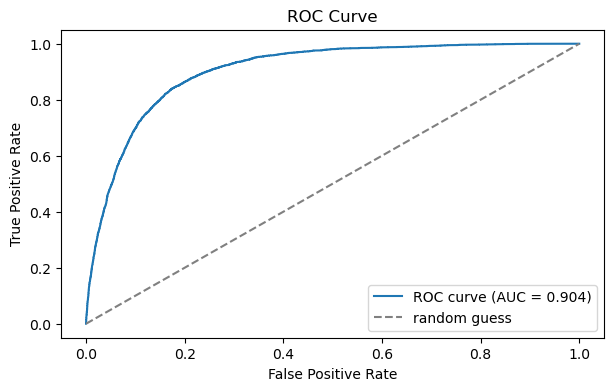

ROC-AUC : 0.9041
Gini    : 0.8082


In [22]:
fpr, tpr, roc_thresholds = roc_curve(y, p_final)
auc = roc_auc_score(y, p_final)
gini = 2 * auc - 1

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print('ROC-AUC :', round(auc, 4))
print('Gini    :', round(gini, 4))


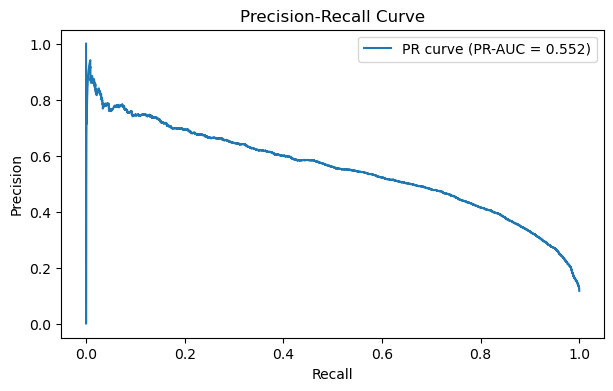

In [23]:
precision, recall, pr_thresholds = precision_recall_curve(y, p_final)
pr_auc = average_precision_score(y, p_final)

plt.plot(recall, precision, label=f'PR curve (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


**Why PR-AUC matters more than ROC-AUC here.** ROC's false positive
rate is FP / (FP + TN). With the true negative count so large (about 88
percent of the data), this denominator is inflated, which makes ROC-AUC look
strong even when the model still lets through a fair number of false
positives relative to the small pool of actual positives. The PR curve never
uses true negatives at all, so it is the more honest picture of how well the
model finds subscribers specifically.

In [24]:
def ks_statistic(y_true, p):
    df = pd.DataFrame({'y': y_true, 'p': p}).sort_values('p', ascending=False)
    df['cum_positive'] = df['y'].cumsum() / df['y'].sum()
    df['cum_negative'] = (1 - df['y']).cumsum() / (1 - df['y']).sum()
    return (df['cum_positive'] - df['cum_negative']).max()

ks = ks_statistic(y, p_final)
print('KS statistic:', round(ks, 4))


KS statistic: 0.6656


KS measures the largest gap between the cumulative share of
subscribers captured and the cumulative share of non-subscribers captured,
as customers are ranked by predicted probability from high to low. A larger
KS means better separation between the two classes.

In [25]:
decile_df = pd.DataFrame({'y': y, 'p': p_final})
decile_df['decile'] = pd.qcut(decile_df['p'].rank(method='first', ascending=False), 10,
                               labels=range(1, 11))

decile_table = decile_df.groupby('decile', observed=True).agg(
    customers=('y', 'size'), subscribers=('y', 'sum'))
decile_table['conversion_rate'] = (decile_table['subscribers'] / decile_table['customers']).round(4)
decile_table['cumulative_capture'] = (decile_table['subscribers'].cumsum()
                                       / decile_table['subscribers'].sum()).round(4)
base_rate = decile_df['y'].mean()
decile_table['lift'] = (decile_table['conversion_rate'] / base_rate).round(2)
decile_table


,customers,subscribers,conversion_rate,cumulative_capture,lift
decile,,,,,
1,3165,1800,0.5687,0.4845,4.84
2,3165,1011,0.3194,0.7567,2.72
3,3164,470,0.1485,0.8832,1.27
4,3165,220,0.0695,0.9424,0.59
5,3165,105,0.0332,0.9707,0.28
6,3164,50,0.0158,0.9841,0.13
7,3165,21,0.0066,0.9898,0.06
8,3164,25,0.0079,0.9965,0.07
9,3165,11,0.0035,0.9995,0.03


Decile 1 (the top 10 percent of customers by predicted probability)
has the highest conversion rate and the highest lift over the base rate.
Cumulative capture shows how much of the total subscriber pool would be
reached by calling only the top few deciles, which is the practical output
a call center would use to decide who to call first.

## 9. Threshold Tuning

The default cutoff of 0.5 is not necessarily the best one for accuracy,
which is the metric this competition is scored on. The cutoff is scanned on
out-of-fold predictions (never on the actual test set) to find the threshold
that maximizes accuracy.


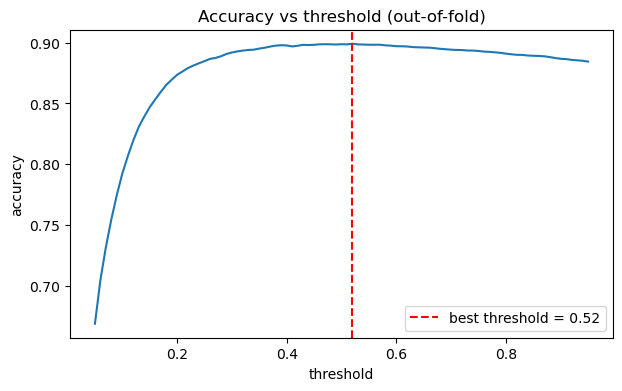

Best threshold : 0.52
Best accuracy  : 0.8992


In [26]:
thresholds_scan = np.linspace(0.05, 0.95, 91)
accuracies = [accuracy_score(y, (p_final >= t).astype(int)) for t in thresholds_scan]

best_idx = int(np.argmax(accuracies))
best_threshold = thresholds_scan[best_idx]
best_accuracy = accuracies[best_idx]

plt.plot(thresholds_scan, accuracies)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'best threshold = {best_threshold:.2f}')
plt.xlabel('threshold')
plt.ylabel('accuracy')
plt.title('Accuracy vs threshold (out-of-fold)')
plt.legend()
plt.show()

print('Best threshold :', round(best_threshold, 2))
print('Best accuracy  :', round(best_accuracy, 4))


In [27]:
y_pred_best = (p_final >= best_threshold).astype(int)
print('At default 0.5 threshold:')
print('  accuracy :', round(accuracy_score(y, y_pred_05), 4))
print('  precision:', round(precision_score(y, y_pred_05), 4))
print('  recall   :', round(recall_score(y, y_pred_05), 4))
print()
print(f'At tuned {best_threshold:.2f} threshold:')
print('  accuracy :', round(accuracy_score(y, y_pred_best), 4))
print('  precision:', round(precision_score(y, y_pred_best), 4))
print('  recall   :', round(recall_score(y, y_pred_best), 4))


At default 0.5 threshold:
  accuracy : 0.8988
  precision: 0.6277
  recall   : 0.3381

At tuned 0.52 threshold:
  accuracy : 0.8992
  precision: 0.6415
  recall   : 0.3198


## 10. Reading the Final Coefficients

Because every feature was WoE transformed first, each coefficient answers a
clean question: how much should this feature's own WoE evidence be trusted
in the final score. A coefficient near 1.0 means "trust this feature's WoE
directly". A coefficient below 1 means the feature is being shrunk, often
because it overlaps with another feature. A negative coefficient means the
feature is acting as a correction against a correlated feature rather than
contributing its raw signal directly.


In [28]:
best_lr.fit(X_woe_train.values, y)
coefficients = pd.Series(best_lr.coef_[0], index=feature_names).sort_values(ascending=False)
coefficients.round(3)


duration_woe     1.195
poutcome_woe     0.878
pdays_woe        0.775
month_woe        0.686
day_woe          0.682
marital_woe      0.665
housing_woe      0.561
loan_woe         0.560
contact_woe      0.551
campaign_woe     0.514
balance_woe      0.487
age_woe          0.441
education_woe    0.431
job_woe          0.189
previous_woe    -0.911
dtype: float64

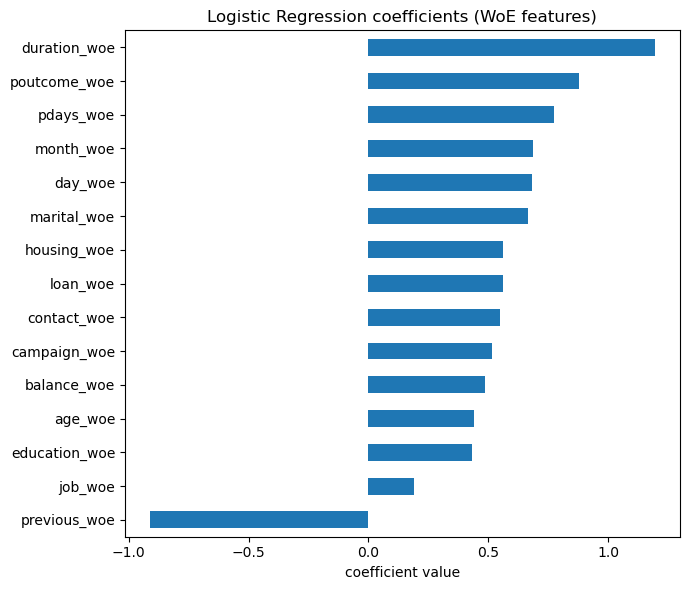

In [29]:
plt.figure(figsize=(7, 6))
coefficients.sort_values().plot(kind='barh')
plt.xlabel('coefficient value')
plt.title('Logistic Regression coefficients (WoE features)')
plt.tight_layout()
plt.show()


## 11. Final Model and Test Predictions

Fit the tuned model on the full training set and generate predictions on
`test.csv` using the threshold selected in Section 9.


In [31]:
best_lr.fit(X_woe_train.values, y)
p_test = best_lr.predict_proba(X_woe_test.values)[:, 1]
predictions = np.where(p_test >= best_threshold, 'yes', 'no')

submission = pd.DataFrame({'ID': test['ID'], 'subscribed': predictions})
submission.to_csv('outputs/submission_logistic_regression.csv', index=False)
submission['subscribed'].value_counts()


subscribed
no     12765
yes      799
Name: count, dtype: int64

## Summary

- Sigmoid and log-odds are the two building blocks of Logistic Regression;
  coefficients are interpreted on the log-odds scale.
- A plain baseline on raw features works but is held back by unscaled
  features and skewed variables that break the linearity assumption.
- WoE transformation fixes the linearity assumption directly and gave the
  strongest out-of-fold PR-AUC of the three feature sets tried.
- L2 (Ridge) shrinks correlated coefficients smoothly and keeps every
  feature; L1 (Lasso) can zero coefficients out entirely; ElasticNet blends
  both. The regularization path plot showed this behavior directly on this
  dataset's WoE features.
- Grid search over penalty, C, and class_weight, scored on PR-AUC (not
  accuracy or ROC-AUC, since both flatter the majority class), selected the
  final model.
- The classification threshold was tuned on out-of-fold predictions, not on
  the test set, to maximize accuracy, the competition's actual metric.
- KS statistic and the decile table give the same ranking-quality picture in
  business terms: which slice of customers to call first for the most
  conversions per call made.
